# Генерация музыкальных последовательностей (MIDI)

В данном ноутбуке решается задача генерации музыки в формате MIDI.
MIDI содержит последовательность событий (нажатие/отпускание нот, паузы, громкость),
которую можно токенизировать и генерировать аналогично тексту.

Обучаемые модели:
1. Simple RNN
2. Однослойная LSTM
3. Многослойная LSTM
4. Двунаправленная LSTM
5. Трансформер (GPT) с нуля

## 0. Настройка окружения

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from utils import (TextDataset, create_dataloaders, train_model,
                   generate_text, compute_perplexity,
                   plot_training_history, print_results_table)
from models import SimpleRNNModel, LSTMModel, MiniGPT
from midi_utils import (load_midi_dataset, midi_to_tokens, tokens_to_midi,
                         token_to_str, print_token_stats, VOCAB_SIZE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch версия: {torch.__version__}')
print(f'CUDA доступна: {torch.cuda.is_available()}')
print(f'Устройство: {device}')

PyTorch версия: 2.8.0+cu129
CUDA доступна: True
Устройство: cuda

## 1. Загрузка и подготовка MIDI-данных

Используем набор классических фортепианных MIDI-файлов.
Поместите `.mid` файлы в директорию `midi_data/`.

In [2]:
# Загрузка и токенизация MIDI-файлов
MIDI_DIR = "maestro-v3.0.0"
encoded = load_midi_dataset(MIDI_DIR, max_files=100)

print(f"\nРазмер словаря: {VOCAB_SIZE}")
print(f"Длина последовательности: {len(encoded):,} токенов")
print_token_stats(encoded)

# Пример первых 20 токенов
print(f"\nПервые 20 токенов:")
for i, t in enumerate(encoded[:20]):
    print(f"  [{i:2d}] {t:3d} = {token_to_str(t)}")

[MIDI] Найдено 100 файлов
[MIDI] Обработано: 100 файлов, ошибок: 0
[MIDI] Общая длина последовательности: 4,495,795 токенов
[MIDI] Размер словаря: 388

Размер словаря: 388
Длина последовательности: 4,495,795 токенов

Статистика токенов:
  NOTE_ON:     749,299 (16.7%)
  NOTE_OFF:    749,299 (16.7%)
  TIME_SHIFT: 2,348,963 (52.2%)
  VELOCITY:    648,234 (14.4%)
  Всего:      4,495,795

Первые 20 токенов:
  [ 0] 355 = TIME_SHIFT_1000ms
  [ 1] 264 = TIME_SHIFT_90ms
  [ 2] 256 = TIME_SHIFT_10ms
  [ 3] 371 = VELOCITY_15
  [ 4]  71 = NOTE_ON_71
  [ 5] 264 = TIME_SHIFT_90ms
  [ 6] 256 = TIME_SHIFT_10ms
  [ 7] 199 = NOTE_OFF_71
  [ 8] 263 = TIME_SHIFT_80ms
  [ 9] 256 = TIME_SHIFT_10ms
  [10] 367 = VELOCITY_11
  [11]  55 = NOTE_ON_55
  [12] 256 = TIME_SHIFT_10ms
  [13] 369 = VELOCITY_13
  [14]  71 = NOTE_ON_71
  [15] 258 = TIME_SHIFT_30ms
  [16] 371 = VELOCITY_15
  [17]  76 = NOTE_ON_76
  [18] 263 = TIME_SHIFT_80ms
  [19] 183 = NOTE_OFF_55

## 2. Создание DataLoader'ов

In [3]:
SEQ_LENGTH = 128
BATCH_SIZE = 64
EPOCHS = 10

train_loader, val_loader = create_dataloaders(encoded, SEQ_LENGTH, BATCH_SIZE)
print(f"Длина последовательности: {SEQ_LENGTH}")
print(f"Размер батча: {BATCH_SIZE}")
print(f"Количество батчей (обуч.): {len(train_loader)}")

[Данные] Обучающая выборка: 31610 примеров, валидационная: 3513 примеров
Длина последовательности: 128
Размер батча: 64
Количество батчей (обуч.): 493

## 3. Обучение моделей

### 3.1. Simple RNN

In [4]:
model_rnn = SimpleRNNModel(VOCAB_SIZE, embed_dim=128, hidden_dim=256, num_layers=1, dropout=0.2)
history_rnn = train_model(model_rnn, train_loader, val_loader, epochs=EPOCHS,
                          device=device, lr=1e-3, model_name="midi_simple_rnn")

Обучение модели: Simple RNN
Параметры: 248,196
Устройство: cuda, AMP: False
  Эпоха   1/10 | Потери обуч.: 3.0541 | Потери вал.: 2.8420 | Перплексия: 17.15
  Эпоха   2/10 | Потери обуч.: 2.7997 | Потери вал.: 2.7344 | Перплексия: 15.40
  Эпоха   3/10 | Потери обуч.: 2.7306 | Потери вал.: 2.6798 | Перплексия: 14.58
  Эпоха   4/10 | Потери обуч.: 2.6492 | Потери вал.: 2.5937 | Перплексия: 13.38
  Эпоха   5/10 | Потери обуч.: 2.5863 | Потери вал.: 2.5419 | Перплексия: 12.70
  Эпоха   6/10 | Потери обуч.: 2.5547 | Потери вал.: 2.5264 | Перплексия: 12.51
  Эпоха   7/10 | Потери обуч.: 2.5314 | Потери вал.: 2.4952 | Перплексия: 12.12
  Эпоха   8/10 | Потери обуч.: 2.5137 | Потери вал.: 2.4829 | Перплексия: 11.98
  Эпоха   9/10 | Потери обуч.: 2.5026 | Потери вал.: 2.4746 | Перплексия: 11.88
  Эпоха  10/10 | Потери обуч.: 2.4962 | Потери вал.: 2.4721 | Перплексия: 11.85
  Лучшие потери на валидации: 2.4721 (перплексия: 11.85)

### 3.2. Однослойная LSTM

In [5]:
model_lstm1 = LSTMModel(VOCAB_SIZE, embed_dim=128, hidden_dim=256, num_layers=1, dropout=0.2)
history_lstm1 = train_model(model_lstm1, train_loader, val_loader, epochs=EPOCHS,
                            device=device, lr=1e-3, model_name="midi_lstm_1layer")

Обучение модели: LSTM (1 слой)
Параметры: 544,644
Устройство: cuda, AMP: False
  Эпоха   1/10 | Потери обуч.: 3.0972 | Потери вал.: 2.8130 | Перплексия: 16.66
  Эпоха   2/10 | Потери обуч.: 2.6695 | Потери вал.: 2.4968 | Перплексия: 12.14
  Эпоха   3/10 | Потери обуч.: 2.4596 | Потери вал.: 2.3659 | Перплексия: 10.65
  Эпоха   4/10 | Потери обуч.: 2.3691 | Потери вал.: 2.3006 | Перплексия: 9.98
  Эпоха   5/10 | Потери обуч.: 2.3165 | Потери вал.: 2.2603 | Перплексия: 9.59
  Эпоха   6/10 | Потери обуч.: 2.2820 | Потери вал.: 2.2359 | Перплексия: 9.35
  Эпоха   7/10 | Потери обуч.: 2.2593 | Потери вал.: 2.2199 | Перплексия: 9.21
  Эпоха   8/10 | Потери обуч.: 2.2450 | Потери вал.: 2.2107 | Перплексия: 9.12
  Эпоха   9/10 | Потери обуч.: 2.2361 | Потери вал.: 2.2056 | Перплексия: 9.08
  Эпоха  10/10 | Потери обуч.: 2.2319 | Потери вал.: 2.2040 | Перплексия: 9.06
  Лучшие потери на валидации: 2.2040 (перплексия: 9.06)

### 3.3. Многослойная LSTM (3 слоя)

In [6]:
model_lstm3 = LSTMModel(VOCAB_SIZE, embed_dim=128, hidden_dim=256, num_layers=3, dropout=0.3)
history_lstm3 = train_model(model_lstm3, train_loader, val_loader, epochs=EPOCHS,
                            device=device, lr=1e-3, model_name="midi_lstm_3layer")

Обучение модели: LSTM (3 слоя)
Параметры: 1,597,316
Устройство: cuda, AMP: False
  Эпоха   1/10 | Потери обуч.: 3.2435 | Потери вал.: 2.9255 | Перплексия: 18.64
  Эпоха   2/10 | Потери обуч.: 2.8594 | Потери вал.: 2.7465 | Перплексия: 15.59
  Эпоха   3/10 | Потери обуч.: 2.7404 | Потери вал.: 2.6701 | Перплексия: 14.44
  Эпоха   4/10 | Потери обуч.: 2.6697 | Потери вал.: 2.5911 | Перплексия: 13.34
  Эпоха   5/10 | Потери обуч.: 2.5916 | Потери вал.: 2.5095 | Перплексия: 12.30
  Эпоха   6/10 | Потери обуч.: 2.5198 | Потери вал.: 2.4309 | Перплексия: 11.37
  Эпоха   7/10 | Потери обуч.: 2.4547 | Потери вал.: 2.3754 | Перплексия: 10.76
  Эпоха   8/10 | Потери обуч.: 2.4154 | Потери вал.: 2.3469 | Перплексия: 10.45
  Эпоха   9/10 | Потери обуч.: 2.3951 | Потери вал.: 2.3342 | Перплексия: 10.32
  Эпоха  10/10 | Потери обуч.: 2.3863 | Потери вал.: 2.3304 | Перплексия: 10.28
  Лучшие потери на валидации: 2.3304 (перплексия: 10.28)

### 3.4. Двунаправленная LSTM

In [7]:
model_bilstm = LSTMModel(VOCAB_SIZE, embed_dim=128, hidden_dim=256, num_layers=2,
                          bidirectional=True, dropout=0.3)
history_bilstm = train_model(model_bilstm, train_loader, val_loader, epochs=EPOCHS,
                             device=device, lr=1e-3, model_name="midi_bilstm")

Обучение модели: Двунаправленная LSTM
Параметры: 2,616,196
Устройство: cuda, AMP: False
  Эпоха   1/10 | Потери обуч.: 0.7267 | Потери вал.: 0.0272 | Перплексия: 1.03
  Эпоха   2/10 | Потери обуч.: 0.0288 | Потери вал.: 0.0237 | Перплексия: 1.02
  Эпоха   3/10 | Потери обуч.: 0.0256 | Потери вал.: 0.0229 | Перплексия: 1.02
  Эпоха   4/10 | Потери обуч.: 0.0242 | Потери вал.: 0.0223 | Перплексия: 1.02
  Эпоха   5/10 | Потери обуч.: 0.0231 | Потери вал.: 0.0218 | Перплексия: 1.02
  Эпоха   6/10 | Потери обуч.: 0.0221 | Потери вал.: 0.0215 | Перплексия: 1.02
  Эпоха   7/10 | Потери обуч.: 0.0212 | Потери вал.: 0.0213 | Перплексия: 1.02
  Эпоха   8/10 | Потери обуч.: 0.0204 | Потери вал.: 0.0212 | Перплексия: 1.02
  Эпоха   9/10 | Потери обуч.: 0.0197 | Потери вал.: 0.0211 | Перплексия: 1.02
  Эпоха  10/10 | Потери обуч.: 0.0193 | Потери вал.: 0.0211 | Перплексия: 1.02
  Лучшие потери на валидации: 0.0211 (перплексия: 1.02)

### 3.5. Трансформер (MiniGPT)

In [8]:
model_gpt = MiniGPT(VOCAB_SIZE, d_model=256, n_heads=4, n_layers=4,
                     d_ff=512, max_len=SEQ_LENGTH, dropout=0.1)
history_gpt = train_model(model_gpt, train_loader, val_loader, epochs=EPOCHS,
                          device=device, lr=3e-4, model_name="midi_gpt", use_amp=True)

Обучение модели: MiniGPT
Параметры: 2,307,972
Устройство: cuda, AMP: True
  Эпоха   1/10 | Потери обуч.: 3.2401 | Потери вал.: 3.0291 | Перплексия: 20.68
  Эпоха   2/10 | Потери обуч.: 2.9850 | Потери вал.: 2.8870 | Перплексия: 17.94
  Эпоха   3/10 | Потери обуч.: 2.8422 | Потери вал.: 2.7380 | Перплексия: 15.46
  Эпоха   4/10 | Потери обуч.: 2.7285 | Потери вал.: 2.6081 | Перплексия: 13.57
  Эпоха   5/10 | Потери обуч.: 2.5982 | Потери вал.: 2.4830 | Перплексия: 11.98
  Эпоха   6/10 | Потери обуч.: 2.5070 | Потери вал.: 2.4065 | Перплексия: 11.09
  Эпоха   7/10 | Потери обуч.: 2.4542 | Потери вал.: 2.3679 | Перплексия: 10.67
  Эпоха   8/10 | Потери обуч.: 2.4261 | Потери вал.: 2.3492 | Перплексия: 10.48
  Эпоха   9/10 | Потери обуч.: 2.4110 | Потери вал.: 2.3376 | Перплексия: 10.36
  Эпоха  10/10 | Потери обуч.: 2.4043 | Потери вал.: 2.3358 | Перплексия: 10.34
  Лучшие потери на валидации: 2.3358 (перплексия: 10.34)

## 4. Сравнение результатов

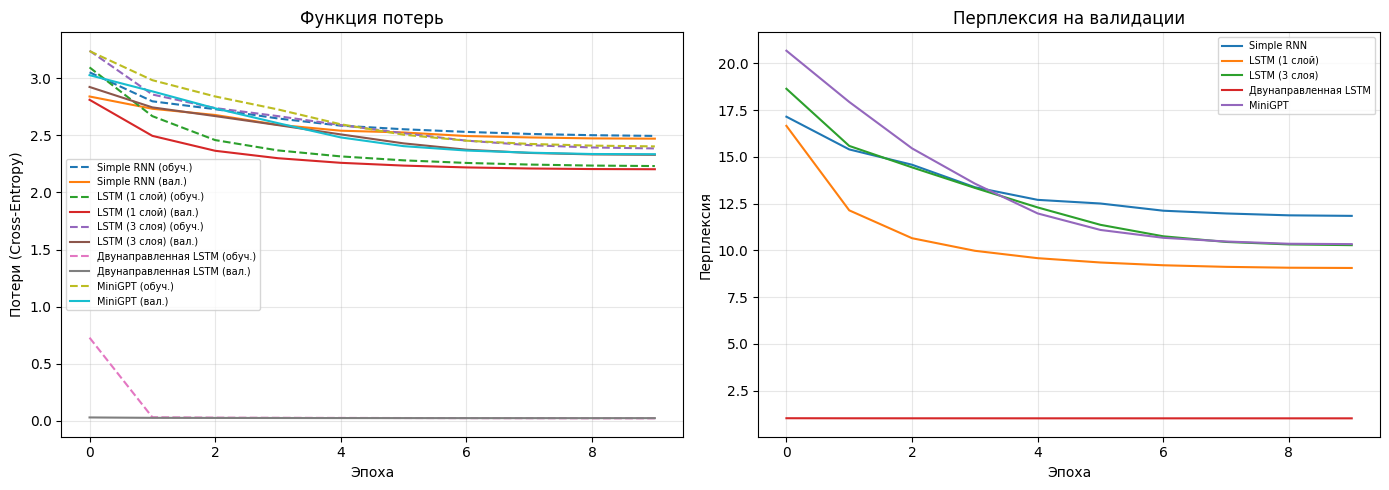

In [9]:
# Визуализация кривых обучения
histories = [history_rnn, history_lstm1, history_lstm3, history_bilstm, history_gpt]
model_names = ["Simple RNN", "LSTM (1 слой)", "LSTM (3 слоя)",
               "Двунаправленная LSTM", "MiniGPT"]

plot_training_history(histories, model_names)

In [10]:
# Таблица результатов
models_list = [model_rnn, model_lstm1, model_lstm3, model_bilstm, model_gpt]
results = []

for model, name, hist in zip(models_list, model_names, histories):
    ppl = compute_perplexity(model.to(device), val_loader, device)
    params = sum(p.numel() for p in model.parameters())
    results.append({
        'name': name,
        'params': params,
        'val_loss': min(hist['val_loss']),
        'perplexity': ppl
    })

print_results_table(results)


Модель                            Параметры  Вал. потери   Перплексия
----------------------------------------------------------------------
Simple RNN                          248,196       2.4721        11.85
LSTM (1 слой)                       544,644       2.2040         9.06
LSTM (3 слоя)                     1,597,316       2.3304        10.28
Двунаправленная LSTM              2,616,196       0.0211         1.02
MiniGPT                           2,307,972       2.3358        10.34

## 5. Генерация музыки

Генерируем MIDI-последовательности с помощью каждой обученной модели.

In [11]:
import os
os.makedirs("generated_midi", exist_ok=True)

# Затравка — начало реальной пьесы из датасета
seed_length = 32
seed_tokens = encoded[:seed_length]

idx_to_token = {i: token_to_str(i) for i in range(VOCAB_SIZE)}

for model, name in zip(models_list, model_names):
    model = model.to(device)
    generated_tokens = generate_text(model, seed_tokens, VOCAB_SIZE, idx_to_token,
                                     length=500, temperature=0.9, device=device, top_k=30)
    # generate_text возвращает строки, преобразуем обратно в ID
    # Используем прямую генерацию через ID
    generated_ids = []
    input_seq = torch.tensor([seed_tokens], dtype=torch.long).to(device)
    model.eval()
    with torch.no_grad():
        for _ in range(500):
            if input_seq.size(1) > 512:
                input_seq = input_seq[:, -512:]
            logits, _ = model(input_seq)
            logits = logits[0, -1, :] / 0.9
            values, indices = torch.topk(logits, 30)
            logits_f = torch.full_like(logits, float('-inf'))
            logits_f.scatter_(0, indices, values)
            probs = torch.softmax(logits_f, dim=0)
            next_id = torch.multinomial(probs, 1).item()
            generated_ids.append(next_id)
            input_seq = torch.cat([input_seq, torch.tensor([[next_id]], device=device)], dim=1)
    
    # Сохраняем MIDI
    all_ids = seed_tokens + generated_ids
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '')
    midi_path = f"generated_midi/{safe_name}.mid"
    tokens_to_midi(all_ids, midi_path)
    print(f"{name}: сгенерировано {len(generated_ids)} токенов -> {midi_path}")

Simple RNN: сгенерировано 500 токенов -> generated_midi/Simple_RNN.mid
LSTM (1 слой): сгенерировано 500 токенов -> generated_midi/LSTM_(1_слой).mid
LSTM (3 слоя): сгенерировано 500 токенов -> generated_midi/LSTM_(3_слоя).mid
Двунаправленная LSTM: сгенерировано 500 токенов -> generated_midi/Двунаправленная_LSTM.mid
MiniGPT: сгенерировано 500 токенов -> generated_midi/MiniGPT.mid

In [12]:
# Генерация с разными температурами (MiniGPT)
print("=== Влияние температуры на генерацию (MiniGPT) ===\n")
model_gpt = model_gpt.to(device)
model_gpt.eval()

for temp in [0.5, 0.8, 1.0, 1.3]:
    generated_ids = []
    input_seq = torch.tensor([seed_tokens], dtype=torch.long).to(device)
    with torch.no_grad():
        for _ in range(500):
            if input_seq.size(1) > 512:
                input_seq = input_seq[:, -512:]
            logits, _ = model_gpt(input_seq)
            logits = logits[0, -1, :] / temp
            values, indices = torch.topk(logits, 30)
            logits_f = torch.full_like(logits, float('-inf'))
            logits_f.scatter_(0, indices, values)
            probs = torch.softmax(logits_f, dim=0)
            next_id = torch.multinomial(probs, 1).item()
            generated_ids.append(next_id)
            input_seq = torch.cat([input_seq, torch.tensor([[next_id]], device=device)], dim=1)
    
    midi_path = f"generated_midi/GPT_temp_{temp}.mid"
    tokens_to_midi(seed_tokens + generated_ids, midi_path)
    
    # Статистика сгенерированных токенов
    note_ons = sum(1 for t in generated_ids if t < 128)
    print(f"Температура = {temp}: {len(generated_ids)} токенов, "
          f"{note_ons} нот -> {midi_path}")

=== Влияние температуры на генерацию (MiniGPT) ===

Температура = 0.5: 500 токенов, 20 нот -> generated_midi/GPT_temp_0.5.mid
Температура = 0.8: 500 токенов, 79 нот -> generated_midi/GPT_temp_0.8.mid
Температура = 1.0: 500 токенов, 91 нот -> generated_midi/GPT_temp_1.0.mid
Температура = 1.3: 500 токенов, 68 нот -> generated_midi/GPT_temp_1.3.mid

## 6. Выводы

### Генерация MIDI-последовательностей:
- **Токенизация MIDI** аналогична посимвольной токенизации текста
- **Словарь** компактный (~388 токенов): ноты, паузы, громкость
- **Временные зависимости** критически важны для музыки (ритм, гармония)

### Сравнение моделей:
- **Simple RNN** — генерирует хаотичные последовательности нот без структуры
- **LSTM** — лучше улавливает ритмические паттерны и повторения
- **Многослойная LSTM** — может выучить более сложные гармонические прогрессии
- **MiniGPT** — лучшее качество, генерирует более музыкально связные фрагменты

### Влияние температуры:
- **Низкая (0.5)** — повторяющиеся паттерны, монотонно но ритмично
- **Средняя (0.8-1.0)** — оптимальный баланс разнообразия и структуры
- **Высокая (1.3)** — более экспериментальная, может терять музыкальную логику

### Отличие от текстовой генерации:
- Музыка имеет более строгую временную структуру
- Гармонические правила — ноты должны "звучать вместе"
- Человек воспринимает ошибки в музыке менее критично, чем в тексте